In [1]:
%pip install ultralytics opencv-python pillow pandas numpy matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.3 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/tom-jerry-object-detection
/kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset
/kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset
/kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/test
/kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/test/images
/kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/train
/kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/train/annotations
/kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/train/images


In [3]:
from pathlib import Path
import os, json, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import cv2
from ultralytics import YOLO
import torch


BASE_DIR = Path("/kaggle/working")
OUT_ROOT = BASE_DIR / "dataset"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

INPUT_ROOT = Path(
    "/kaggle/input/competitions/tom-jerry-object-detection/"
    "Tom_and_Jerry_Kaggle_dataset/"
    "Tom_and_Jerry_Kaggle_dataset"
)

SRC_TRAIN_IMG = INPUT_ROOT / "train/images"
SRC_TRAIN_JSON = INPUT_ROOT / "train/annotations/train.json"
SRC_TEST_IMG = INPUT_ROOT / "test/images"

print("SRC_TRAIN_IMG:", SRC_TRAIN_IMG, "n=", len(list(SRC_TRAIN_IMG.glob("*.jpg"))))
print("SRC_TRAIN_JSON:", SRC_TRAIN_JSON, "exists=", SRC_TRAIN_JSON.exists())
print("SRC_TEST_IMG:", SRC_TEST_IMG, "n=", len(list(SRC_TEST_IMG.glob("*.jpg"))))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
SRC_TRAIN_IMG: /kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/train/images n= 727
SRC_TRAIN_JSON: /kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/train/annotations/train.json exists= True
SRC_TEST_IMG: /kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/test/images n= 180


In [4]:
TRAIN_IMG_DIR = OUT_ROOT / "train/images"
TRAIN_LAB_DIR = OUT_ROOT / "train/labels"
VAL_IMG_DIR   = OUT_ROOT / "val/images"
VAL_LAB_DIR   = OUT_ROOT / "val/labels"

for p in [TRAIN_IMG_DIR, TRAIN_LAB_DIR, VAL_IMG_DIR, VAL_LAB_DIR]:
    p.mkdir(parents=True, exist_ok=True)

def hard_copy(src: Path, dst: Path):
    shutil.copy2(src, dst)

In [5]:
def coco_xywh_to_yolo_norm(bbox_xywh, W, H):
    x, y, w, h = bbox_xywh
    cx = (x + w / 2) / W
    cy = (y + h / 2) / H
    bw = w / W
    bh = h / H
    # clip
    cx = float(np.clip(cx, 0.0, 1.0))
    cy = float(np.clip(cy, 0.0, 1.0))
    bw = float(np.clip(bw, 0.0, 1.0))
    bh = float(np.clip(bh, 0.0, 1.0))
    return cx, cy, bw, bh


with open(SRC_TRAIN_JSON, "r") as f:
    coco = json.load(f)

# 类别映射：COCO category_id -> 0..K-1
cats = sorted(coco["categories"], key=lambda x: x["id"])
catid2cls = {c["id"]: i for i, c in enumerate(cats)}
class_names = [c["name"] for c in cats]
print("Classes:", class_names)

# image_id -> info
imgid2info = {im["id"]: im for im in coco["images"]}

# image_id -> annotations
imgid2anns = {}
for ann in coco["annotations"]:
    imgid2anns.setdefault(ann["image_id"], []).append(ann)

# split
all_ids = list(imgid2info.keys())
random.seed(42)
random.shuffle(all_ids)

val_ratio = 0.1
n_val = int(len(all_ids) * val_ratio)
val_ids = set(all_ids[:n_val])
train_ids = all_ids[n_val:]

print("train:", len(train_ids), "val:", len(val_ids))

def write_label_txt(img_info, anns, out_txt: Path):
    W, H = img_info["width"], img_info["height"]
    lines = []
    for ann in anns:
        if "bbox" not in ann:
            continue
        cls = catid2cls[ann["category_id"]]
        cx, cy, bw, bh = coco_xywh_to_yolo_norm(ann["bbox"], W, H)
        lines.append(f"{cls} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
    out_txt.write_text("\n".join(lines) + ("\n" if lines else ""))

missing = 0
for img_id in all_ids:
    info = imgid2info[img_id]
    fname = info["file_name"]
    src_img = SRC_TRAIN_IMG / fname
    if not src_img.exists():
        missing += 1
        continue

    anns = imgid2anns.get(img_id, [])

    if img_id in val_ids:
        dst_img = VAL_IMG_DIR / src_img.name
        dst_txt = VAL_LAB_DIR / (src_img.stem + ".txt")
    else:
        dst_img = TRAIN_IMG_DIR / src_img.name
        dst_txt = TRAIN_LAB_DIR / (src_img.stem + ".txt")

    hard_copy(src_img, dst_img)
    write_label_txt(info, anns, dst_txt)

print("Done. missing:", missing)
print("train imgs:", len(list(TRAIN_IMG_DIR.glob("*.jpg"))), "val imgs:", len(list(VAL_IMG_DIR.glob("*.jpg"))))

Classes: ['Tom', 'Jerry']
train: 655 val: 72
Done. missing: 0
train imgs: 655 val imgs: 72


In [6]:
yaml_path = BASE_DIR / "dataset.yaml"

data_yaml = {
    "path": str(OUT_ROOT),
    "train": "train/images",
    "val": "val/images",
    "names": {i: n for i, n in enumerate(class_names)}
}

with open(yaml_path, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print("dataset.yaml saved:", yaml_path, "exists:", yaml_path.exists())
print(yaml_path.read_text())

dataset.yaml saved: /kaggle/working/dataset.yaml exists: True
path: /kaggle/working/dataset
train: train/images
val: val/images
names:
  0: Tom
  1: Jerry



In [7]:
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

model = YOLO("yolov8s.pt")

model.train(
    data=str(yaml_path),
    epochs=100,
    imgsz=640,      # 因为图像是 640×480
    batch=32,       # OOM 就改 16
    device=0,
    workers=4,
    amp=True,
    project="yolo_runs",
    name="tj_p100",
    seed = 42
)

cuda available: True
gpu: Tesla P100-PCIE-16GB
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tj_p100, nbs=64, nms=False, opset=None, optimize=False, opt

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fe83ab742c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

[PosixPath('runs/detect/yolo_runs/tj_p100/weights'), PosixPath('runs/detect/yolo_runs/tj_p100/val_batch1_pred.jpg'), PosixPath('runs/detect/yolo_runs/tj_p100/val_batch1_labels.jpg'), PosixPath('runs/detect/yolo_runs/tj_p100/BoxP_curve.png'), PosixPath('runs/detect/yolo_runs/tj_p100/BoxPR_curve.png'), PosixPath('runs/detect/yolo_runs/tj_p100/val_batch0_pred.jpg'), PosixPath('runs/detect/yolo_runs/tj_p100/train_batch1890.jpg'), PosixPath('runs/detect/yolo_runs/tj_p100/train_batch2.jpg'), PosixPath('runs/detect/yolo_runs/tj_p100/args.yaml'), PosixPath('runs/detect/yolo_runs/tj_p100/train_batch1891.jpg'), PosixPath('runs/detect/yolo_runs/tj_p100/train_batch0.jpg'), PosixPath('runs/detect/yolo_runs/tj_p100/val_batch0_labels.jpg'), PosixPath('runs/detect/yolo_runs/tj_p100/confusion_matrix.png'), PosixPath('runs/detect/yolo_runs/tj_p100/results.png'), PosixPath('runs/detect/yolo_runs/tj_p100/BoxR_curve.png'), PosixPath('runs/detect/yolo_runs/tj_p100/BoxF1_curve.png'), PosixPath('runs/detect/y

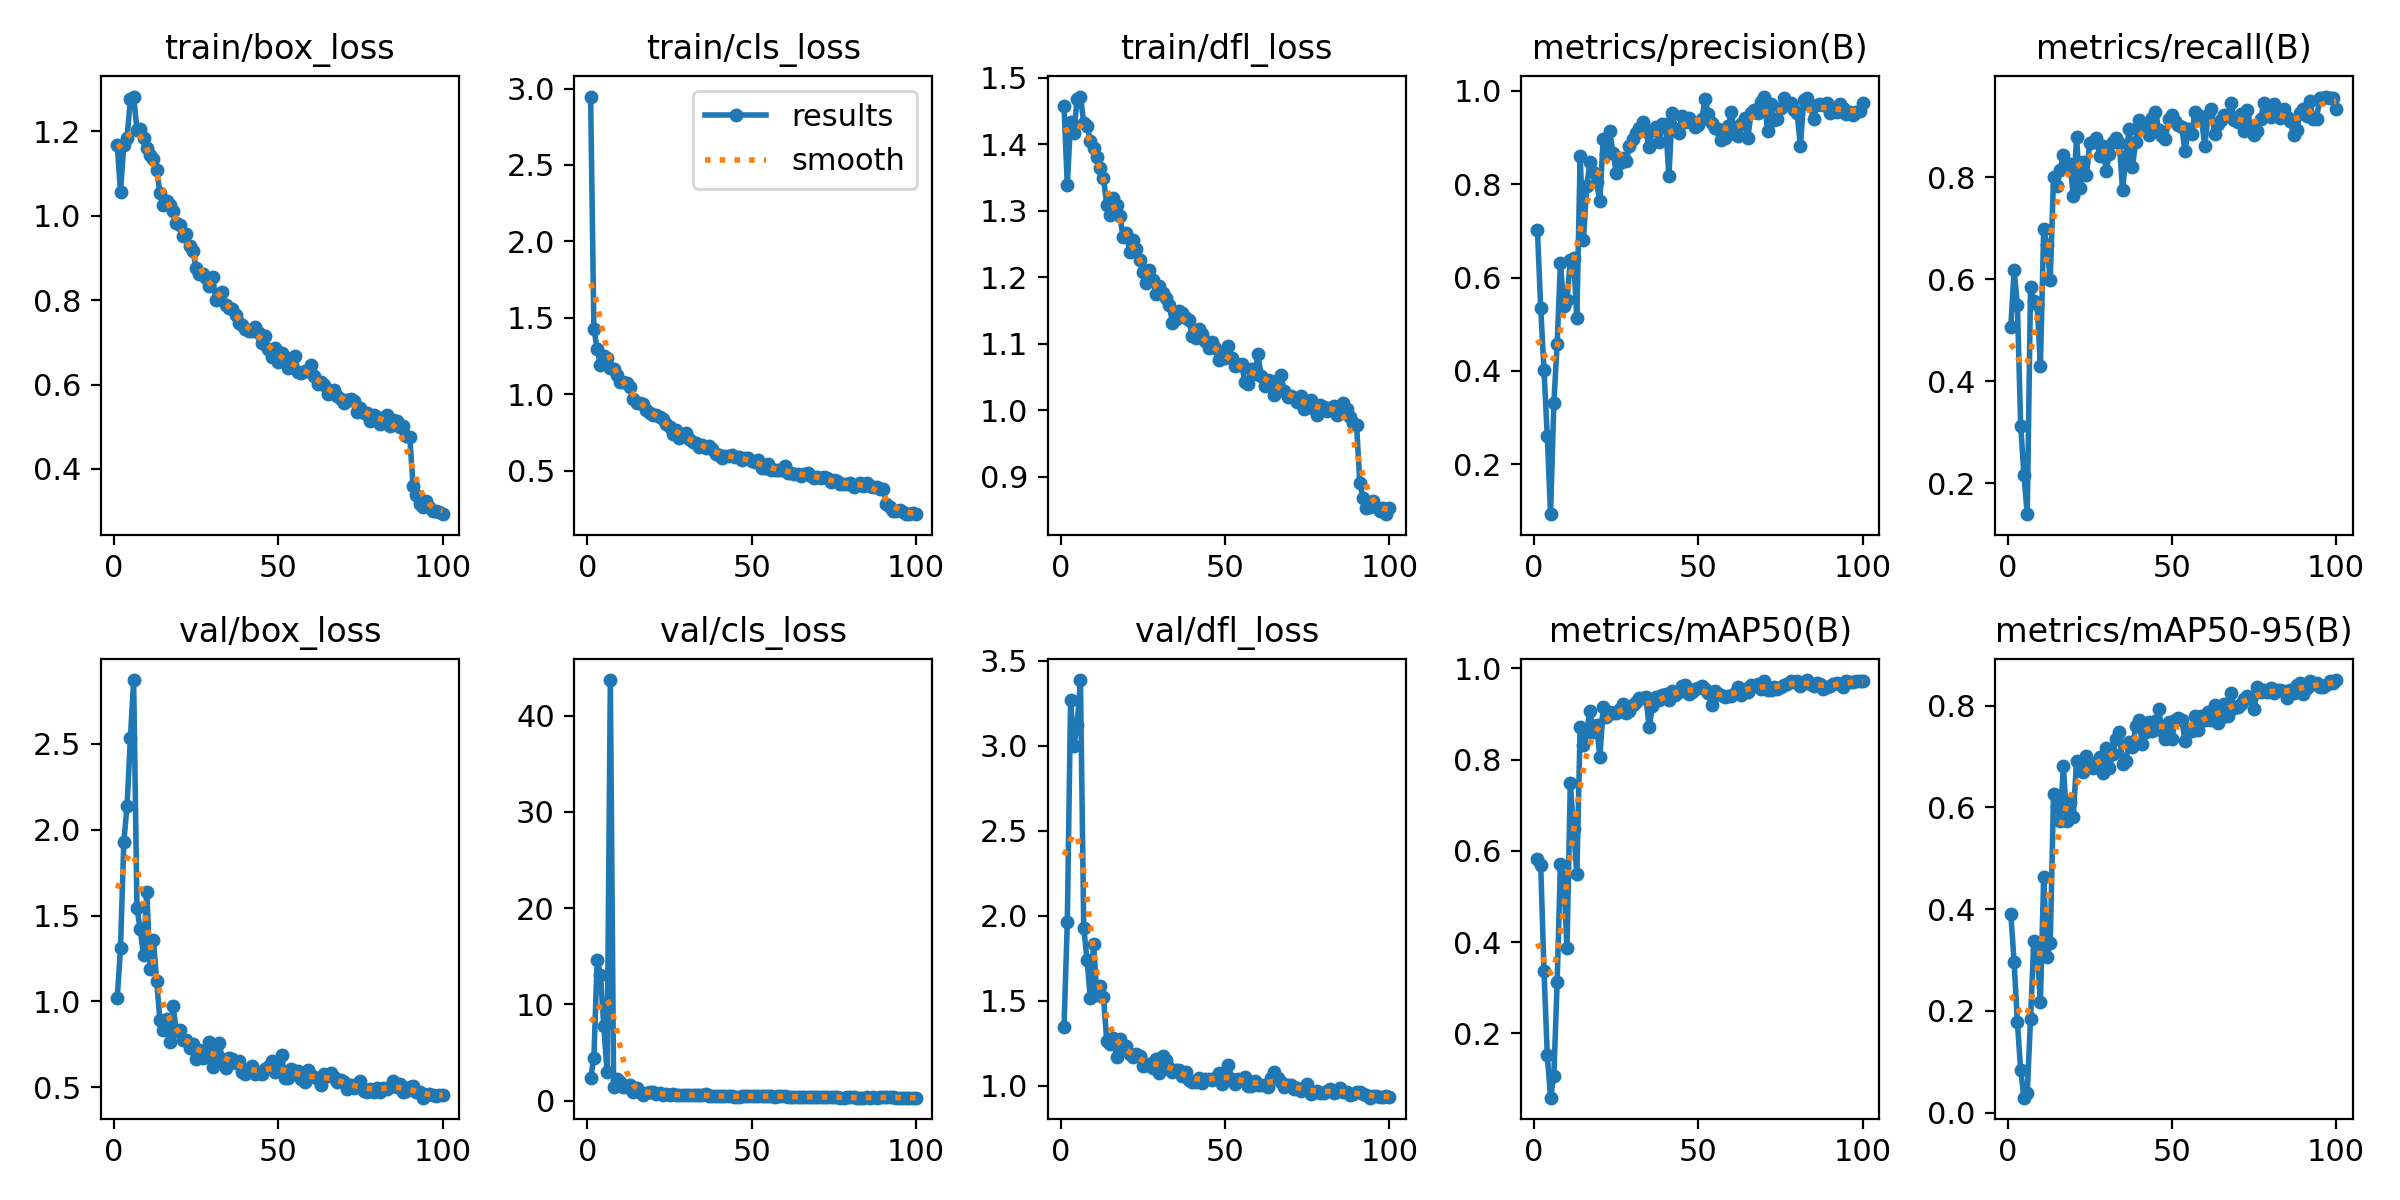

In [8]:
from pathlib import Path
from PIL import Image
from IPython.display import display

run_dir = Path("runs/detect/yolo_runs/tj_p100")

print(list(run_dir.iterdir()))

display(Image.open(run_dir / "results.png"))

In [9]:
best_pt = Path("runs/detect/yolo_runs/tj_p100/weights/best.pt")
model = YOLO(str(best_pt))

metrics = model.val(
    data=str(yaml_path),
    split="val",
    device=0,
    verbose=False,
    plots=True
)

# print(metrics)
# print("Check plots under:", Path("yolo_runs/tj_p100"))
{
    "precision": metrics.box.mp,
    "recall": metrics.box.mr,
    "mAP50": metrics.box.map50,
    "mAP50-95": metrics.box.map
}

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1408.3±430.3 MB/s, size: 65.5 KB)
val: Scanning /kaggle/working/dataset/val/labels.cache... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72 27.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.6it/s 1.4s0.4s
                   all         72         89      0.975      0.933      0.972      0.854
Speed: 4.0ms preprocess, 5.4ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val


{'precision': np.float64(0.9747812266616219),
 'recall': np.float64(0.9333704521805388),
 'mAP50': np.float64(0.9724421015718117),
 'mAP50-95': np.float64(0.8535806549514667)}

In [10]:
def containment_suppress(xyxy, conf, cls, area_ratio_thr=6.0, contain_thr=0.95):
    """
    删掉：被更高分同类小框“包含”的低分大框
    - area_ratio_thr: 大框面积 / 小框面积 >= 该阈值 才判定为“明显更大”
    - contain_thr: 小框有多少比例在大框内（用交集面积/小框面积近似）
    """
    if len(conf) <= 1:
        return xyxy, conf, cls

    # 按 conf 从高到低
    order = np.argsort(-conf)
    xyxy = xyxy[order]
    conf = conf[order]
    cls  = cls[order]

    keep = np.ones(len(conf), dtype=bool)

    areas = (xyxy[:,2]-xyxy[:,0]) * (xyxy[:,3]-xyxy[:,1])

    for j in range(len(conf)):
        if not keep[j]:
            continue
        # 用高分框去“剔除”后面的低分框
        x1j,y1j,x2j,y2j = xyxy[j]
        for i in range(j+1, len(conf)):
            if not keep[i]:
                continue
            if cls[i] != cls[j]:
                continue

            x1,y1,x2,y2 = xyxy[i]

            # 计算小框在大框内的比例：inter_area / small_area
            ix1 = max(x1j, x1); iy1 = max(y1j, y1)
            ix2 = min(x2j, x2); iy2 = min(y2j, y2)
            iw = max(0.0, ix2 - ix1); ih = max(0.0, iy2 - iy1)
            inter = iw * ih

            small_area = areas[i]
            big_area   = areas[j]

            # 这里假设 j 是更高分框，但它可能是小框；所以同时判断两种包含关系
            # case A: j(高分) 是小框，i(低分) 是大框 -> 删 i
            contain_small_in_big = inter / max(1e-9, small_area)  # 小框被包含比例（若 i 是小框）
            # 我们还需要反向：j 小框是否在 i 大框内
            # 直接算 j 在 i 内
            jx1,jy1,jx2,jy2 = x1j,y1j,x2j,y2j
            ix1b = max(x1, jx1); iy1b = max(y1, jy1)
            ix2b = min(x2, jx2); iy2b = min(y2, jy2)
            iw2 = max(0.0, ix2b - ix1b); ih2 = max(0.0, iy2b - iy1b)
            inter2 = iw2 * ih2
            j_area = areas[j]
            contain_j_in_i = inter2 / max(1e-9, j_area)

            # 如果 i(低分) 基本包含 j(高分)，且面积更大很多 -> 删 i
            if contain_j_in_i >= contain_thr and (areas[i] / max(1e-9, areas[j])) >= area_ratio_thr:
                keep[i] = False

    # 还原为原顺序不重要；你后面直接遍历即可
    return xyxy[keep], conf[keep], cls[keep]

In [11]:
from pathlib import Path
import cv2
import pandas as pd
from ultralytics import YOLO

# 1) 自动找 best.pt（避免路径写错）
best_candidates = list(Path("/kaggle/working").rglob("weights/best.pt"))
assert best_candidates, "没找到 weights/best.pt：请确认你训练已完成且 best.pt 存在"
best_pt = best_candidates[0]
print("Using best_pt:", best_pt)

model = YOLO(str(best_pt))

# 2) 类别映射：YOLO cls -> LabelName
# 你训练时 names 应该是 {0:'Tom', 1:'Jerry'}；这里显式写死，最不容易错
CLS2NAME = {0: "Tom", 1: "Jerry"}

CONF_THR = 0.035

def clamp_int(x, lo, hi):
    return int(max(lo, min(int(round(float(x))), hi)))

pred_rows = []
test_imgs = sorted(list(SRC_TEST_IMG.glob("*.jpg")))
print("Test images:", len(test_imgs))

for img_path in test_imgs:
    image_id = img_path.stem
    im = cv2.imread(str(img_path))
    H, W = im.shape[:2]

    r = model.predict(
        source=str(img_path),
        conf=CONF_THR,
        iou=0.5,
        verbose=False,
        device=0,
        max_det=10
    )[0]

    dets = []
    if r.boxes is not None and len(r.boxes) > 0:
        xyxy = r.boxes.xyxy.cpu().numpy()
        conf = r.boxes.conf.cpu().numpy()
        cls  = r.boxes.cls.cpu().numpy().astype(int)

        xyxy, conf, cls = containment_suppress(xyxy, conf, cls)

        for (x1, y1, x2, y2), c, k in zip(xyxy, conf, cls):
            # 绝对像素坐标 + int
            x1 = clamp_int(x1, 0, W)
            y1 = clamp_int(y1, 0, H)
            x2 = clamp_int(x2, 0, W)
            y2 = clamp_int(y2, 0, H)

            # 保证 xmin<=xmax, ymin<=ymax
            xmin, xmax = (x1, x2) if x1 <= x2 else (x2, x1)
            ymin, ymax = (y1, y2) if y1 <= y2 else (y2, y1)

            label = CLS2NAME.get(int(k), "Tom")  # 兜底
            dets.append(f"{label} {float(c):.4f} {xmin} {ymin} {xmax} {ymax}")

    # 3) 空预测 dummy：必须非空 + 极低置信度
    if len(dets) == 0:
        dets = ["Tom 0.0001 0 0 1 1"]

    pred_rows.append({
        "ImageId": image_id,
        "PredictionString": " ".join(dets)
    })

# 保存 submission.csv 到 /kaggle/working（用于下载/上传 late submission）
sub = pd.DataFrame(pred_rows, columns=["ImageId", "PredictionString"])
out_path = Path("/kaggle/working/submission.csv")
sub.to_csv(out_path, index=False)

print("Saved:", out_path, "rows:", len(sub))
sub.head()

Using best_pt: /kaggle/working/runs/detect/yolo_runs/tj_p100/weights/best.pt
Test images: 180
Saved: /kaggle/working/submission.csv rows: 180


,ImageId,PredictionString
0,0107031a-AhSweetMouseStoryofLife19655460,Tom 0.9577 167 138 426 479 Jerry 0.8647 154 26...
1,036051d4-MouseCleaning19485100,Tom 0.9359 235 189 622 472
2,0cec82eb-TomicEnergy19657800,Jerry 0.9598 189 152 342 306
3,0e92459e-OnARoll2021900,Jerry 0.9149 295 141 427 282
4,0f20d1c4-TomicEnergy19652400,Jerry 0.9372 323 154 474 326 Tom 0.7852 0 0 45...


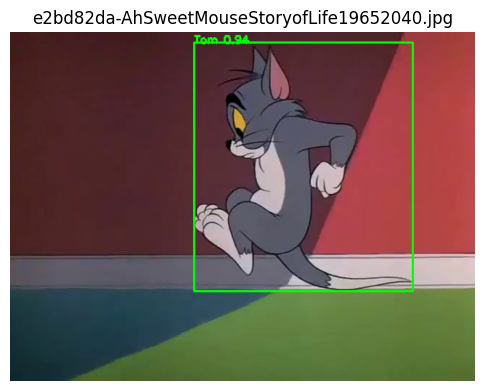

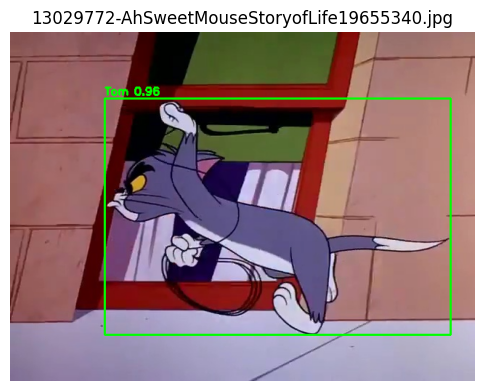

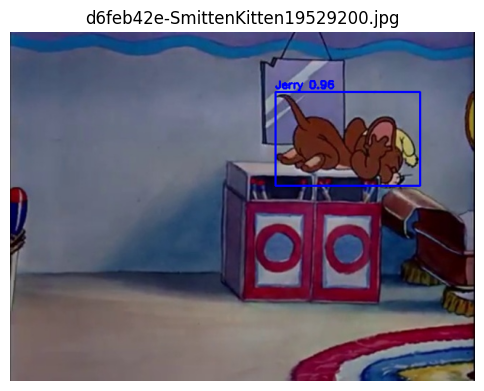

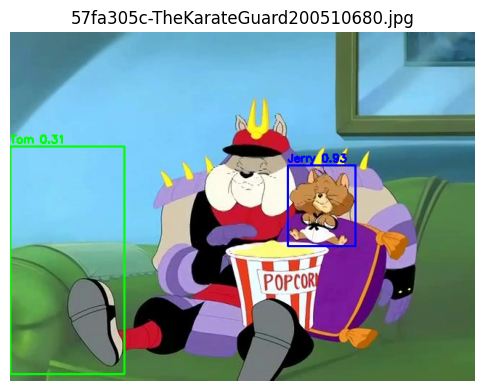

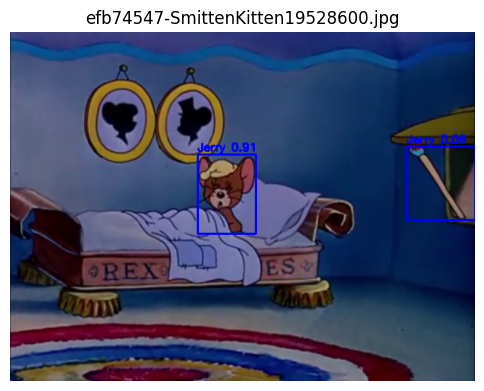

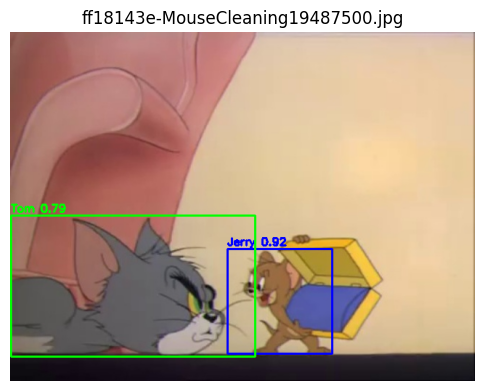

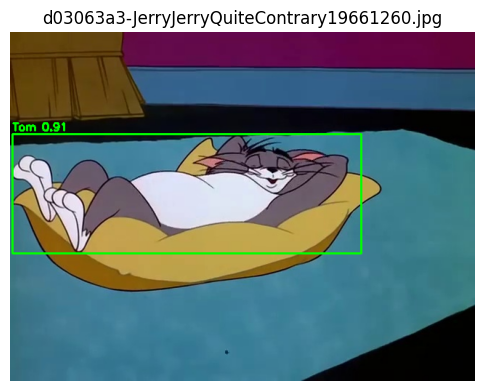

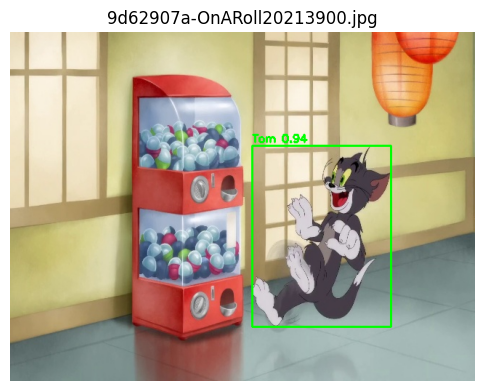

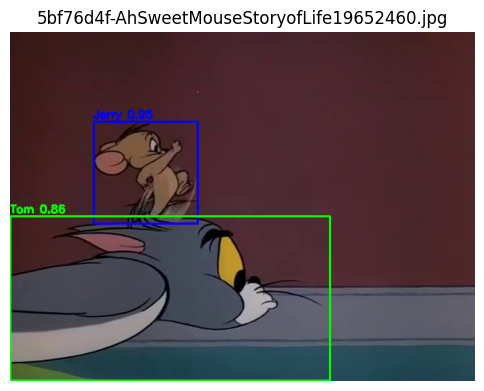

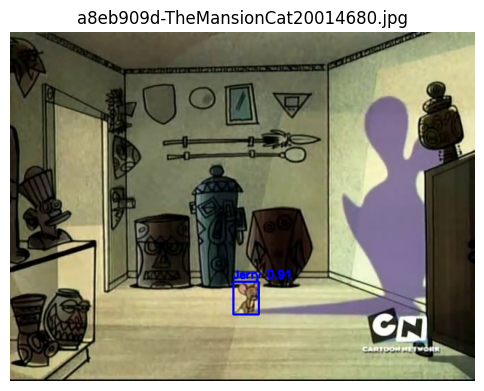

In [12]:
import random
import matplotlib.pyplot as plt

# 随机挑几张图
sample_imgs = random.sample(test_imgs, 10)

# check all
# sample_imgs = test_imgs

for img_path in sample_imgs:
    im = cv2.imread(str(img_path))
    im_draw = im.copy()
    H, W = im.shape[:2]

    r = model.predict(
        source=str(img_path),
        conf=CONF_THR,
        iou=0.5,
        verbose=False,
        device=0
    )[0]

    if r.boxes is not None and len(r.boxes) > 0:
        xyxy = r.boxes.xyxy.cpu().numpy()
        conf = r.boxes.conf.cpu().numpy()
        cls  = r.boxes.cls.cpu().numpy().astype(int)

        for (x1,y1,x2,y2), c, k in zip(xyxy, conf, cls):

            x1 = clamp_int(x1, 0, W)
            y1 = clamp_int(y1, 0, H)
            x2 = clamp_int(x2, 0, W)
            y2 = clamp_int(y2, 0, H)

            label = CLS2NAME.get(int(k), "Tom")

            color = (0,255,0) if label=="Tom" else (255,0,0)

            cv2.rectangle(im_draw,(x1,y1),(x2,y2),color,2)

            text = f"{label} {c:.2f}"
            cv2.putText(
                im_draw,
                text,
                (x1,max(15,y1-5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                color,
                2
            )

    plt.figure(figsize=(6,6))
    plt.title(img_path.name)
    plt.imshow(cv2.cvtColor(im_draw, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

In [13]:
for p in sorted(Path("/kaggle/working").iterdir()):
    print(" -", p)

 - /kaggle/working/.virtual_documents
 - /kaggle/working/dataset
 - /kaggle/working/dataset.yaml
 - /kaggle/working/runs
 - /kaggle/working/submission.csv
 - /kaggle/working/yolo26n.pt
 - /kaggle/working/yolov8s.pt
